# 🚍 Metromove Transit Data Analysis and Predictive Modelling

## Introduction

Public transit systems generate large volumes of operational data every
day — covering who travels, when, from where, and at what cost. When
analyzed effectively, this data can reveal patterns in ridership
behavior, pricing structures, and network performance that are not
immediately obvious from day-to-day operations.

This project explores a dataset from **Metromove**, a transit network
offering multiple modes of transport (Ferry, Train, and Bus) across a
series of stations including Central, Airport, Downtown, North Station,
South Point, and West End. The dataset captures key trip-level details
such as departure and arrival stations, mode of transport, day of week,
passenger count, fare amount, and trip duration.

### Objectives

The goals of this project are to:

1. **Explore and understand** the structure and distribution of the
   transit dataset through exploratory data analysis (EDA).
2. **Identify patterns and relationships** between key variables —
   such as how station, day of week, and mode of transport relate to
   passenger volume and fare pricing.
3. **Evaluate the relationships between core numeric variables** (fare
   amount, passenger count, and trip duration) to determine which
   features carry the strongest predictive signal.
4. **Build a predictive model** capable of forecasting outcomes such as
   fare amount or ridership demand, based on the patterns uncovered
   during analysis.
5. **Translate findings into actionable recommendations** for improving
   scheduling, pricing strategy, and overall network efficiency.

### Why This Matters

Transit operators face a constant balancing act between service
availability, cost, and passenger experience. By understanding where
demand is unpredictable, whether pricing reflects that demand, and
which factors truly drive ridership patterns, Metromove can make more
informed, data-driven decisions — improving both operational efficiency
and revenue outcomes.

The sections that follow walk through this analysis step by step: from
initial data exploration, through statistical relationships between
variables, to a final set of recommendations grounded in the data.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import collections as counter
df = pd.read_excel("Public_Transport_Trips_EDA (1).xlsx")

In [2]:
df.tail()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
995,TRIP0996,train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,FERRY,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN
999,TRIP1000,train,Airport,West End,2024-01-01 22:39:00,34.0,8.168803,21.0,2024-02-11,Tuesday,NaN,NaN


In [3]:
df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [4]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [5]:
df.shape

(1000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

In [7]:
missing_pct = df.isnull().mean()*100
drop_cols = missing_pct[missing_pct>40.0].index

In [8]:
df.drop(columns=drop_cols, inplace=True)

In [9]:
drop_cols = ["Trip_ID","Departure_Time","Trip_Date"]
df.drop(columns=drop_cols,inplace=True)

In [10]:
df.describe()

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes
count,900.000000,900.000000,900.000000
mean,49.154444,25.360742,94.270000
std,27.698270,14.464556,50.634982
min,1.000000,0.500576,5.000000
25%,25.000000,12.818196,49.750000
50%,48.000000,25.403856,97.500000
75%,72.000000,37.866623,138.000000
max,99.000000,49.945184,179.000000


In [11]:
df.describe(include="object")

,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week
count,1000,1000,1000,1000
unique,9,7,7,7
top,Bus,North Station,South Point,Sunday
freq,147,171,171,167


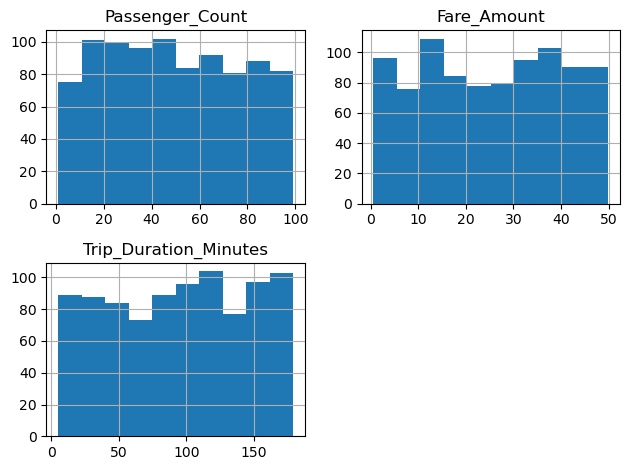

In [12]:
df.hist()
plt.tight_layout()

In [13]:
df.columns

Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes',
       'Day_of_Week'],
      dtype='object')

### Total merto move by mode of trasport

In [14]:
df.loc[df["Mode_of_Transport"] == "train", "Mode_of_Transport"]="Train"
df.loc[df["Mode_of_Transport"] == "FERRY", "Mode_of_Transport"]="Ferry"
df.loc[df["Mode_of_Transport"] == "fErry", "Mode_of_Transport"]="Ferry"
df.loc[df["Mode_of_Transport"] == "BUS", "Mode_of_Transport"]="Bus"
df.loc[df["Mode_of_Transport"] == "bus", "Mode_of_Transport"]="Bus"
df.loc[df["Mode_of_Transport"] == "Tram", "Mode_of_Transport"]="Train"

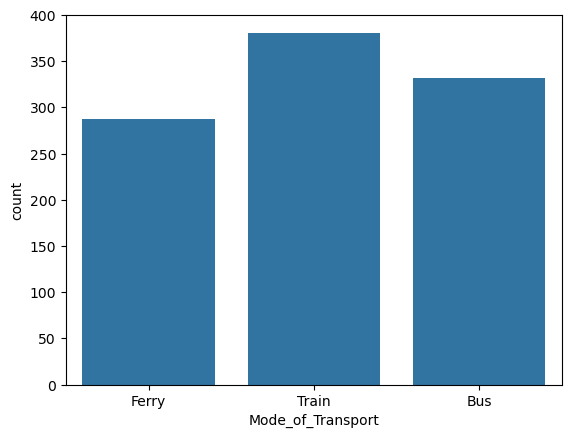

In [15]:
sns.countplot(x="Mode_of_Transport",data=df);

Mode_of_Transport
Train    381
Bus      332
Ferry    287
Name: count, dtype: int64

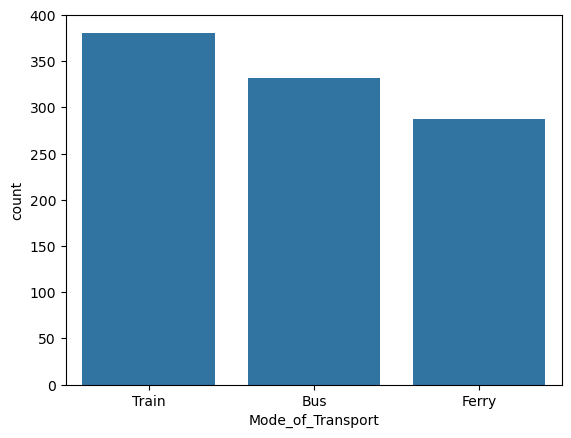

In [16]:
ax = sns.countplot(x=df["Mode_of_Transport"],order=df["Mode_of_Transport"].value_counts (ascending =False).index)
df["Mode_of_Transport"].value_counts().head()

### Total Metro move at Departure station

Departure_Station
North Station    171
Downtown         167
West End         159
Central          158
Airport          157
Name: count, dtype: int64

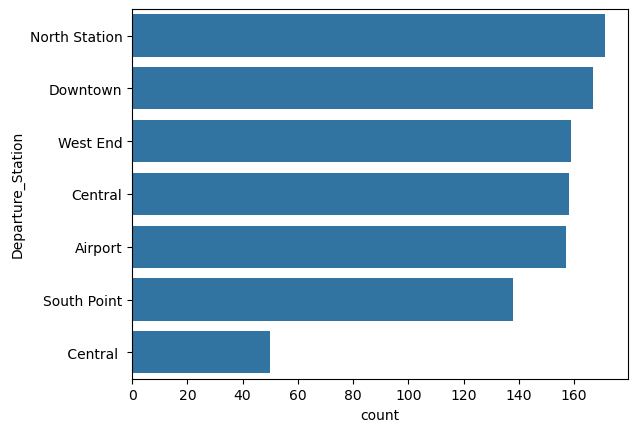

In [17]:
x = sns.countplot(y=df["Departure_Station"],order=df["Departure_Station"].value_counts (ascending =False).index)
df.loc[df["Departure_Station"] == "Central", "Departure_Station"]="Central"
df["Departure_Station"].value_counts().head()

## Total metro move at Arrival Station

In [18]:
df.columns

Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes',
       'Day_of_Week'],
      dtype='object')

Arrival_Station
South Point    171
Downtown       168
West End       163
Airport        163
Central        160
Name: count, dtype: int64

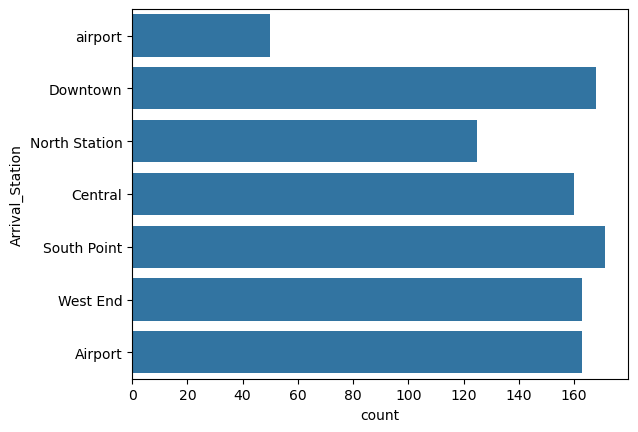

In [19]:
ax=sns.countplot(y="Arrival_Station",data=df)
df["Arrival_Station"].value_counts().head()

## Total Metro move By Passenger Count

In [20]:
df.columns

Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes',
       'Day_of_Week'],
      dtype='object')

Day_of_Week
Sunday       167
Tuesday      147
Saturday     146
Monday       142
Friday       142
Wednesday    138
Thursday     118
Name: count, dtype: int64

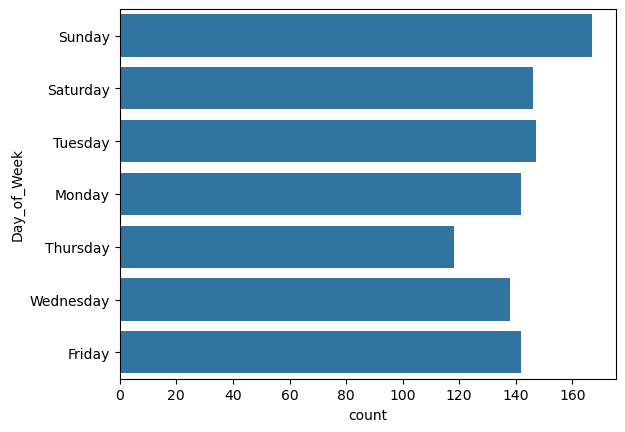

In [21]:
sns.countplot(y="Day_of_Week",data=df)
df["Day_of_Week"].value_counts()

In [22]:
df.columns

Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes',
       'Day_of_Week'],
      dtype='object')

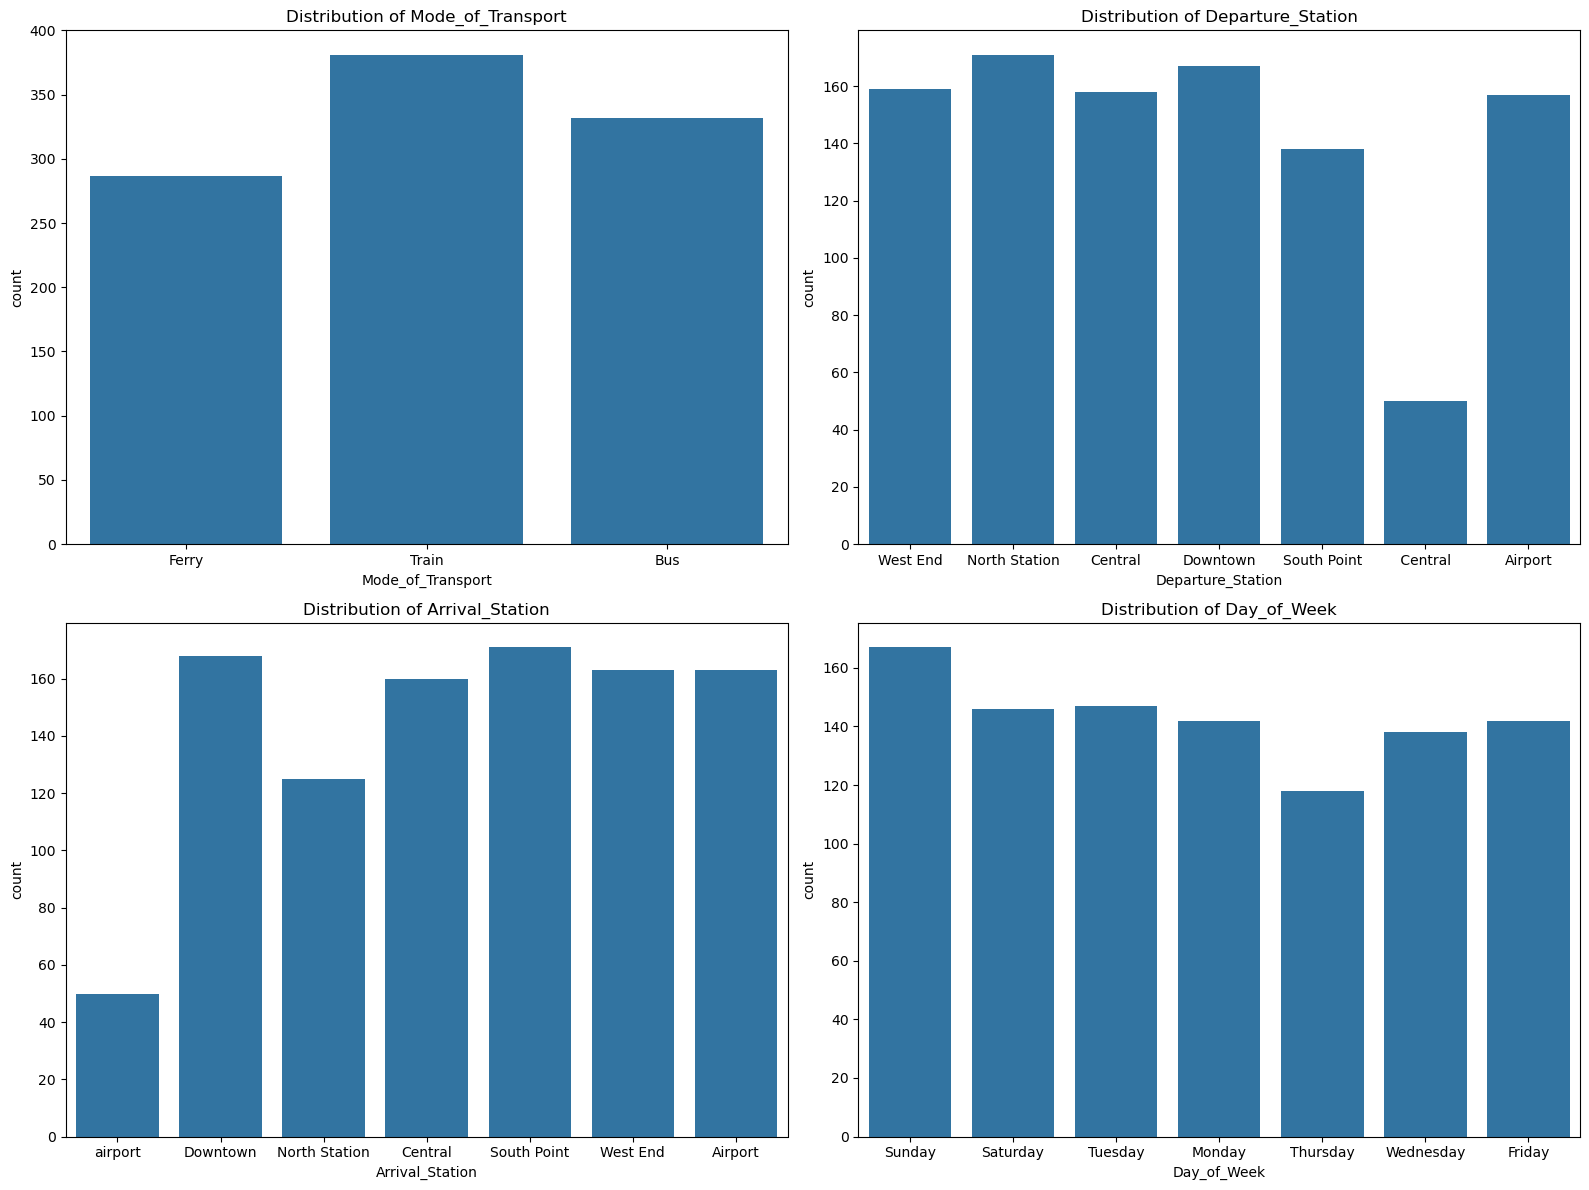

In [23]:
cat_cols = df.select_dtypes(include="object").columns
n_cols=2
n_rows = -(-len(cat_cols)//n_cols)
fig, axes = plt.subplots(n_rows,n_cols, figsize=(8*n_cols,6*n_cols))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):   
 sns.countplot(data=df,x=col,ax=ax)
 ax.set_title(f"Distribution of {col}")
 ax.set_xlabel(col)
 

for ax, in axes[len (cat_cols):]:
    ax.set_visible(False)
    
plt.tight_layout()
plt.show()

## Station-Level Analysis: Passenger Volume & Fare Behavior

To understand how demand and pricing vary across our transit network, we
examined passenger counts and fare amounts across all eight departure
stations. This comparison helps identify which stations experience the
greatest ridership pressure and whether current fare structures align
with usage patterns.

---

### Key Finding 1: Ridership is broadly balanced, but two stations stand out

Across most departure stations, median passenger counts fall within a
similar range, pointing to a well-distributed network where no single
station is overwhelmingly dominant. However, **Central** and **Airport**
show noticeably wider variability in passenger volume compared to the
rest of the network. This suggests these two locations experience less
predictable demand — likely driven by peak commuter surges at Central
and flight-schedule-driven traffic at Airport.

**Implication:** These two stations are prime candidates for adaptive
scheduling strategies, where service frequency responds to real-time or
time-of-day demand rather than a fixed timetable.

---

### Key Finding 2: Fare pricing is consistent, but not fully demand-aligned

Fare amounts remain relatively stable across stations, with only modest
increases at stations like **South Point** and **Airport** — consistent
with longer average trip distances or premium routing. Importantly,
fare variability does *not* mirror the passenger volume variability seen
in Finding 1, meaning pricing is currently **not dynamically responsive**
to demand fluctuations.

**Implication:** There is an opportunity to explore demand-based or
distance-based pricing models, particularly at high-variability stations,
to both improve revenue capture and better manage peak-time congestion.


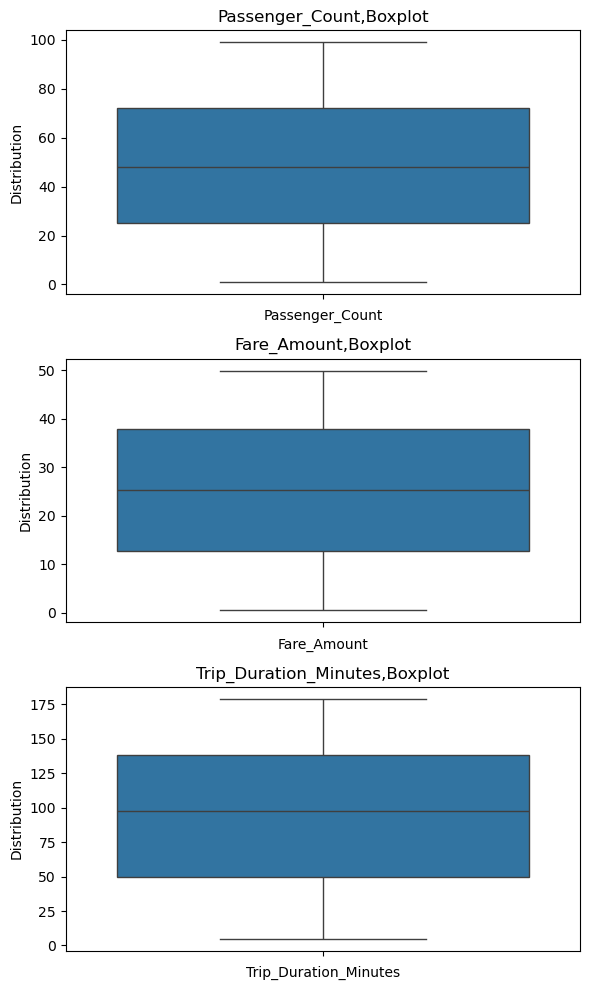

In [24]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols
n_cols=1
n_rows = -(-len(num_cols)//n_cols)
fig, axes = plt.subplots(n_rows,n_cols, figsize=(6*n_cols,10*n_cols))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):   
 sns.boxplot(df[col],ax=ax)
 ax.set_title(f"{col},Boxplot")
 ax.set_xlabel(col)
 ax.set_ylabel("Distribution")

for ax, in axes[len (num_cols):]:
    ax.set_visible(False)
    
plt.tight_layout()
plt.show()

### Recommendations
- Continue monitoring fare amounts and trip durations to support operational planning and service improvements.
- Utilize trip duration and passenger count insights to optimize route scheduling and resource allocation.
- Maintain consistent data collection and validation practices to ensure reliable future analyses.

In [25]:
# Calculate the correlation matrix for the three numeric variables
correlation_matrix = df[['Fare_Amount', 'Passenger_Count', 'Trip_Duration_Minutes']].corr()

# Print the numeric correlation values
print(correlation_matrix)

                       Fare_Amount  Passenger_Count  Trip_Duration_Minutes
Fare_Amount               1.000000          0.01525              -0.046738
Passenger_Count           0.015250          1.00000               0.021590
Trip_Duration_Minutes    -0.046738          0.02159               1.000000


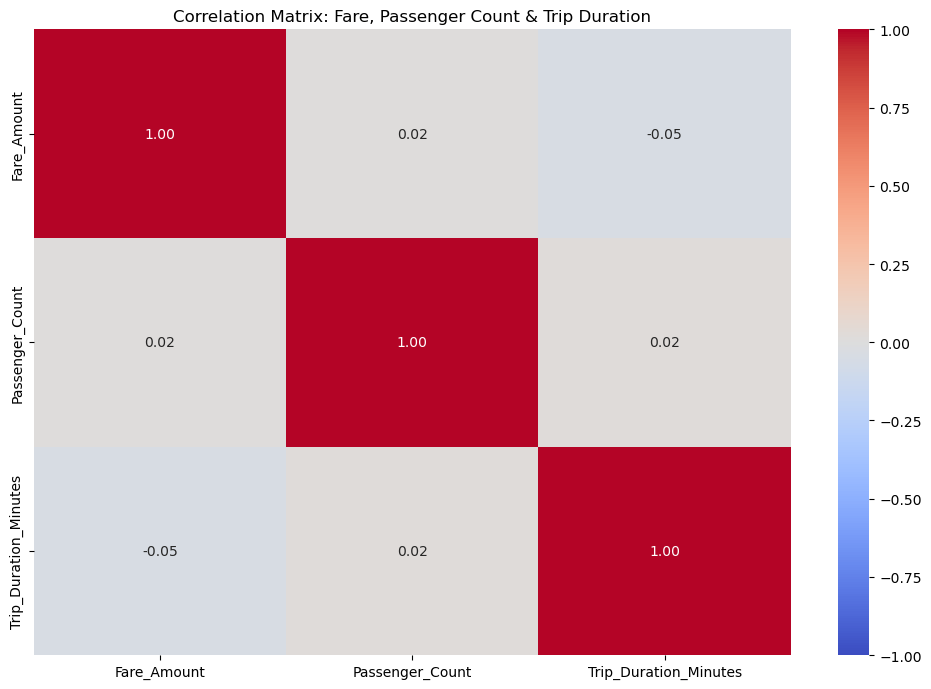

In [26]:
# Set a smaller figure size so it fits neatly in the notebook
plt.figure(figsize=(10, 7))


# Plot the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

plt.title('Correlation Matrix: Fare, Passenger Count & Trip Duration')
plt.tight_layout()
plt.show()


- The correlation matrix confirms **no meaningful linear relationship**
  between Fare_Amount, Passenger_Count, and Trip_Duration_Minutes —
  all off-diagonal values round to 0.02, 0.02, and -0.05.
- **Fare_Amount vs Trip_Duration_Minutes (-0.05):** a very weak negative
  relationship, essentially negligible — longer trips are not priced
  higher.
- **Fare_Amount vs Passenger_Count (0.02):** virtually no relationship —
  fare does not scale with the number of passengers.
- **Passenger_Count vs Trip_Duration_Minutes (0.02):** also negligible —
  group size has no bearing on how long a trip takes.
- The diagonal values of 1.00 are expected, since each variable
  perfectly correlates with itself.

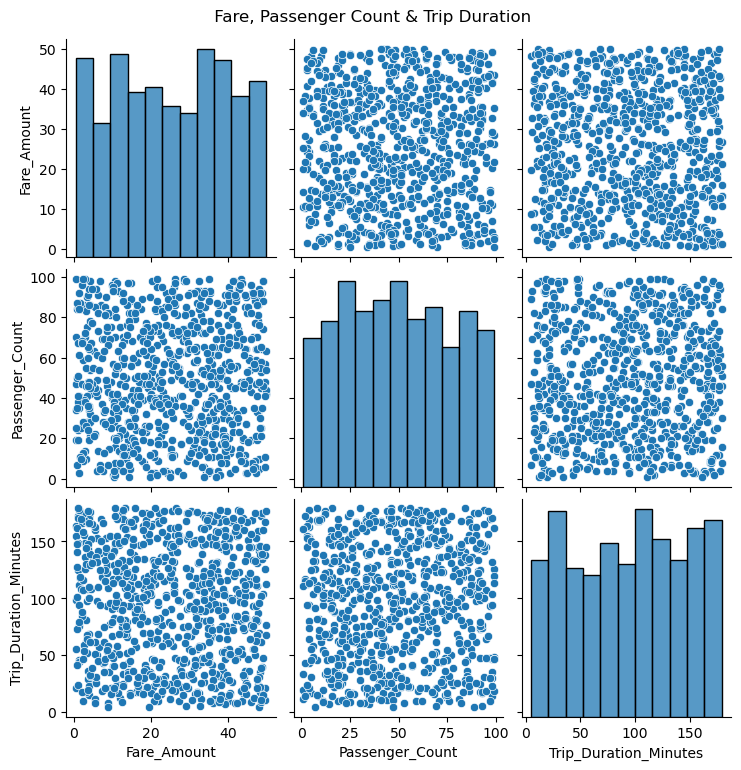

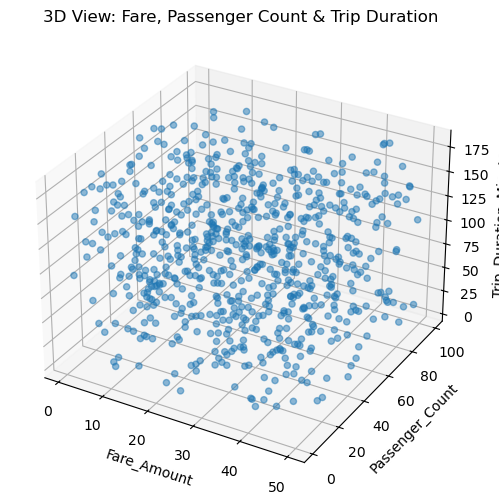

In [27]:

from mpl_toolkits.mplot3d import Axes3D

# --- Pairwise scatter plots with distributions on the diagonal ---
sns.pairplot(df[['Fare_Amount', 'Passenger_Count', 'Trip_Duration_Minutes']])
plt.suptitle(' Fare, Passenger Count & Trip Duration', y=1.02)
plt.show()

# --- 3D scatter plot to check for joint patterns across all three variables ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Fare_Amount'], df['Passenger_Count'], df['Trip_Duration_Minutes'], alpha=0.5)
ax.set_xlabel('Fare_Amount')
ax.set_ylabel('Passenger_Count')
ax.set_zlabel('Trip_Duration_Minutes')
plt.title('3D View: Fare, Passenger Count & Trip Duration')
plt.show()


## 🔗 Multivariate Analysis: Fare, Passenger Count & Trip Duration

### Observations from the Pair Plot

- The scatter panels for every variable pair (Fare_Amount vs
  Passenger_Count, Fare_Amount vs Trip_Duration_Minutes, and
  Passenger_Count vs Trip_Duration_Minutes) show **evenly scattered,
  uniform point clouds** with no visible clusters, curves, or diagonal
  trends.
- The diagonal histograms show that each variable is **roughly
  uniformly distributed** across its range (Fare_Amount ~0–50,
  Passenger_Count ~0–100, Trip_Duration_Minutes ~0–175), rather than
  following a normal or skewed distribution.
- No pairing shows evidence of banding, tiering, or grouping — the data
  points fill the full plot area evenly, reinforcing that these
  variables move independently of one another.

### Observations from the 3D Scatter

- The 3D scatter plot shows points **densely and evenly filling the
  entire cube** formed by Fare_Amount, Passenger_Count, and
  Trip_Duration_Minutes.
- There is **no visible plane, cluster, or curved surface** that would
  suggest a combined/joint relationship between the three variables.
- The even, cube-filling spread visually confirms the near-zero
  correlation values found earlier — even when viewed together in three
  dimensions, no hidden structure emerges.



## Recommendations 

Based on the exploratory data analysis of the MetroMove transit dataset, the following recommendations are proposed to improve operational efficiency, customer satisfaction, and data-driven decision-making.

### 1. Optimize Resource Allocation Across Transit Modes
The distribution of trips indicates varying demand across buses, trains, and ferries. Management should allocate vehicles, staff, and maintenance resources according to the demand for each transportation mode to improve service efficiency and reduce operational costs.

### 2. Improve Service at High-Traffic Stations
The analysis shows that some departure and arrival stations experience considerably higher passenger activity than others. These stations should be prioritized for increased vehicle availability, better scheduling, and improved passenger facilities to reduce congestion and waiting times.

### 3. Review Low-Usage Stations
Stations with consistently lower passenger traffic should be evaluated to determine the underlying causes. Possible improvements include adjusting service schedules, enhancing accessibility, or introducing promotional initiatives to encourage higher utilization.

### 4. Adjust Operations Based on Weekly Demand
Passenger movement varies across different days of the week. Transit schedules should be optimized by increasing service frequency during high-demand days while reducing excess capacity during lower-demand periods to improve operational efficiency.

### 5. Maintain Consistent Fare Pricing
The fare distribution appears relatively stable with no significant extreme values. Maintaining a transparent and consistent pricing strategy will help sustain customer confidence while periodic reviews can ensure fares remain competitive and financially sustainable.

### 6. Monitor Trip Duration Performance
Trip durations exhibit natural variation but do not show significant abnormal values. Continuous monitoring of travel times can help identify delays, improve route planning, and maintain reliable service delivery.
